# Phase 5 — Politique de ciblage et ROI

On traduit tout ce qui précède en **décision** : *à qui envoyer quel e-mail, et combien cela rapporte-t-il ?*

Une **politique de ciblage** π associe à chaque client $x$ une action $\pi(x) \in \{\text{aucun e-mail}, \text{e-mail Hommes}, \text{e-mail Femmes}\}$. On veut la politique qui maximise le **profit attendu**.

**Plan** :
1. Poser des hypothèses économiques explicites (marge, coût d'envoi).
2. Savoir **évaluer** une politique qu'on n'a jamais appliquée, grâce aux données randomisées.
3. Comparer des politiques simples et des politiques fondées sur l'uplift, avec intervalles de confiance.
4. Analyse de sensibilité : quand la conclusion change-t-elle ?
5. Recommandation chiffrée.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

predictions = pd.read_csv("../data/uplift_predictions.csv")   # produit par le notebook 04
W = predictions["segment"].map({"No E-Mail": 0, "Mens E-Mail": 1, "Womens E-Mail": 2}).to_numpy()
spend = predictions["spend"].to_numpy()
n = len(predictions)

COULEURS = {"personne": "#8a8984", "tous : e-mail Hommes": "#2a78d6", "tous : e-mail Femmes": "#eb6834",
            "uplift naïf (2 modèles)": "#e87ba4", "hybride (Hommes moyen + modèle Femmes)": "#1baf7a"}
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
                     "grid.color": "#e6e5e1", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "font.size": 10})
print(n, "clients")

64000 clients


## 1. Hypothèses économiques

Le jeu de données donne le **chiffre d'affaires** (`spend`), pas le profit. Il faut deux hypothèses, posées explicitement et testées en sensibilité (section 5) :

| Paramètre | Valeur de référence | Justification | Plage testée |
|---|---|---|---|
| **Marge brute** sur le chiffre d'affaires | **30 %** | ordre de grandeur courant en distribution d'habillement après coûts des marchandises et logistique | 10 % à 60 % |
| **Coût complet par e-mail envoyé** | **0,05 $** | l'envoi lui-même coûte < 0,01 $, mais on ajoute la création, l'outil de routage et surtout le coût de **désabonnement / fatigue** (chaque e-mail use un peu la relation) | 0 à 0,50 $ |

**Profit d'une politique, par client** :

$$\text{profit}(\pi) = \text{marge} \times \mathbb{E}[\text{spend} \mid \pi] - \text{coût} \times P(\pi(X) \neq \text{aucun})$$

Le profit de référence est celui de « n'envoyer à personne » : c'est ce que les clients rapportent sans campagne. On raisonne sur le **profit incrémental** par rapport à cette référence.

In [2]:
MARGE = 0.30
COUT_EMAIL = 0.05
panier_moyen = predictions.loc[predictions["conversion"] == 1, "spend"].mean()

# Uplift en $ de chiffre d'affaires, option (b) de la phase 4 : uplift de conversion × panier moyen
uplift_hommes = predictions["uplift_conv_hommes"].to_numpy() * panier_moyen
uplift_femmes = predictions["uplift_conv_femmes"].to_numpy() * panier_moyen
ate_hommes = spend[W == 1].mean() - spend[W == 0].mean()
print(f"Panier moyen : {panier_moyen:.1f} $   |   ATE e-mail Hommes sur la dépense : {ate_hommes:.3f} $")

Panier moyen : 116.4 $   |   ATE e-mail Hommes sur la dépense : 0.770 $


## 2. Évaluer une politique qu'on n'a jamais appliquée

C'est le problème de l'**évaluation hors politique** (*off-policy evaluation*). On veut le chiffre d'affaires moyen si **chaque client avait reçu l'action choisie par π**. Mais chaque client n'a reçu qu'une action, tirée au hasard.

**L'astuce grâce à la randomisation** : regroupons les clients selon l'action que π leur attribue. Parmi ceux à qui π attribue l'e-mail Hommes, environ 1/3 ont **justement reçu** l'e-mail Hommes dans l'expérience, et ils ont été tirés au hasard. Leur dépense moyenne estime donc sans biais ce qu'aurait dépensé tout ce groupe sous π. D'où l'estimateur, stratifié par action :

$$\hat V(\pi) = \sum_{a} \underbrace{P(\pi(X) = a)}_{\text{part des clients à qui } \pi \text{ attribue } a} \times \underbrace{\overline{Y}\big[W = a,\ \pi(X) = a\big]}_{\text{dépense moyenne de ceux qui ont reçu } a \text{ par hasard}}$$

C'est une version de l'estimateur par **pondération inverse de la probabilité** (IPW) normalisée (dite de Hájek). Elle ne vaut que parce que l'assignation est **aléatoire** et **indépendante des prédictions**. C'est le cas ici : les prédictions sont hors échantillon (phase 4) et ne dépendent que des covariables pré-traitement.

**Vérification** : pour une politique uniforme (« tout le monde reçoit l'e-mail Hommes »), l'estimateur doit redonner exactement la moyenne du groupe e-mail Hommes.

In [3]:
def valeur_politique(pi, y=spend, indices=None):
    # Estimation de E[y] si chaque client recevait l'action pi(x) (estimateur stratifié par action)
    if indices is not None:
        pi, w, y = pi[indices], W[indices], y[indices]
    else:
        w = W
    valeur = 0.0
    for a in range(3):
        cible = pi == a
        if cible.any():
            observes = cible & (w == a)
            # Garde-fou : si la politique cible une poignée de clients dont aucun n'a reçu a par hasard
            # (arrive dans les cas extrêmes de la grille de sensibilité), on se rabat sur la moyenne du bras a
            moyenne = y[observes].mean() if observes.any() else y[w == a].mean()
            valeur += cible.mean() * moyenne
    return valeur

def profit(pi, marge=MARGE, cout=COUT_EMAIL, indices=None):
    part_contactee = (pi != 0).mean() if indices is None else (pi[indices] != 0).mean()
    return marge * valeur_politique(pi, indices=indices) - cout * part_contactee

tous_hommes = np.ones(n, dtype=int)
print(f"Estimateur pour « tous e-mail Hommes » : {valeur_politique(tous_hommes):.4f} $")
print(f"Moyenne du groupe e-mail Hommes        : {spend[W == 1].mean():.4f} $")

Estimateur pour « tous e-mail Hommes » : 1.4226 $
Moyenne du groupe e-mail Hommes        : 1.4226 $


## 3. Les politiques candidates

1. **Personne** : référence, aucun envoi.
2. **Tous : e-mail Hommes** : la meilleure politique *uniforme* d'après la phase 2.
3. **Tous : e-mail Femmes** : pour comparaison.
4. **Uplift naïf** : pour chaque client, on choisit l'action au plus grand gain prédit, $\text{marge} \times \hat\tau_a(x) - \text{coût}$, et on n'envoie rien si les deux gains sont négatifs. Cette politique utilise **les deux** modèles d'uplift de la phase 4.
5. **Hybride** : identique, mais l'uplift de l'e-mail Hommes est remplacé par son **effet moyen** (ATE). La phase 4 a montré que son hétérogénéité prédite était du bruit. On ne garde le modèle que là où il a été **validé** (e-mail Femmes, p = 0,002).

La politique hybride illustre un principe général : **n'utiliser une estimation individualisée que si elle a fait ses preuves hors échantillon**, et sinon se rabattre sur la moyenne, plus fiable.

In [4]:
def politiques(marge=MARGE, cout=COUT_EMAIL):
    def meilleure_action(gain_hommes, gain_femmes):
        return np.select([(gain_hommes >= gain_femmes) & (gain_hommes > 0), (gain_femmes > gain_hommes) & (gain_femmes > 0)],
                         [1, 2], default=0)
    gain_femmes = marge * uplift_femmes - cout
    return {
        "personne": np.zeros(n, dtype=int),
        "tous : e-mail Hommes": np.ones(n, dtype=int),
        "tous : e-mail Femmes": np.full(n, 2),
        "uplift naïf (2 modèles)": meilleure_action(marge * uplift_hommes - cout, gain_femmes),
        "hybride (Hommes moyen + modèle Femmes)": meilleure_action(np.full(n, marge * ate_hommes - cout), gain_femmes),
    }

pols = politiques()
pd.DataFrame({nom: {"aucun e-mail": (pi == 0).mean(), "e-mail Hommes": (pi == 1).mean(), "e-mail Femmes": (pi == 2).mean()}
              for nom, pi in pols.items()}).T.style.format("{:.0%}")

,aucun e-mail,e-mail Hommes,e-mail Femmes
personne,100%,0%,0%
tous : e-mail Hommes,0%,100%,0%
tous : e-mail Femmes,0%,0%,100%
uplift naïf (2 modèles),3%,70%,27%
hybride (Hommes moyen + modèle Femmes),0%,79%,21%


### Intervalles de confiance par bootstrap apparié

Pour comparer deux politiques, on rééchantillonne les **clients** (avec remise) et on recalcule les profits de **toutes** les politiques sur le **même** échantillon bootstrap. Cet appariement est essentiel : les politiques partagent beaucoup de clients et d'actions. La différence de profit entre deux politiques est donc bien plus précise que chaque profit pris isolément.

⚠️ Limite : les prédictions d'uplift sont gardées fixes. Le bootstrap capture la variabilité de l'évaluation, pas celle de l'entraînement des modèles. Les intervalles sont donc un peu **optimistes** pour les politiques fondées sur l'uplift.

In [5]:
rng = np.random.default_rng(42)
N_BOOT = 1000
echantillons = [rng.integers(0, n, n) for _ in range(N_BOOT)]

def evaluer_politiques(pols, marge=MARGE, cout=COUT_EMAIL, reference="personne", comparaison="tous : e-mail Hommes"):
    boot = {nom: np.array([profit(pi, marge, cout, idx) for idx in echantillons]) for nom, pi in pols.items()}
    lignes = []
    for nom, pi in pols.items():
        vs_ref = boot[nom] - boot[reference]
        vs_cmp = boot[nom] - boot[comparaison]
        lignes.append({"politique": nom, "profit / client ($)": profit(pi, marge, cout),
                       "incrémental vs personne": profit(pi, marge, cout) - profit(pols[reference], marge, cout),
                       "IC95 bas": np.percentile(vs_ref, 2.5), "IC95 haut": np.percentile(vs_ref, 97.5),
                       "vs tous Hommes": profit(pi, marge, cout) - profit(pols[comparaison], marge, cout),
                       "IC95 bas ": np.percentile(vs_cmp, 2.5), "IC95 haut ": np.percentile(vs_cmp, 97.5)})
    return pd.DataFrame(lignes).set_index("politique")

resultats = evaluer_politiques(pols)
resultats.round(4)

,profit / client ($),incrémental vs personne,IC95 bas,IC95 haut,vs tous Hommes,IC95 bas,IC95 haut
politique,,,,,,,
personne,0.1958,0.0000,0.0000,0.0000,-0.1809,-0.2649,-0.0948
tous : e-mail Hommes,0.3768,0.1809,0.0948,0.2649,0.0000,0.0000,0.0000
tous : e-mail Femmes,0.2732,0.0773,0.0003,0.1496,-0.1036,-0.1913,-0.0053
uplift naïf (2 modèles),0.3634,0.1676,0.0867,0.2433,-0.0134,-0.0621,0.0401
hybride (Hommes moyen + modèle Femmes),0.3998,0.2040,0.1083,0.2910,0.0230,-0.0163,0.0672


**Lecture (marge 30 %, coût 0,05 $)** :
- **Tous : e-mail Hommes** rapporte ≈ **+0,18 $ de profit incrémental par client**, avec un intervalle de confiance nettement positif. Pour 100 000 clients, cela fait ≈ 18 000 $ de profit supplémentaire pour 5 000 $ de coûts d'envoi.
- **Tous : e-mail Femmes** fait nettement moins bien (≈ −0,10 $ par client par rapport à l'e-mail Hommes).
- **Uplift naïf** fait **un peu moins bien** que « tous e-mail Hommes » (−0,013 $ par client, non significatif). En se fiant à l'hétérogénéité inventée du modèle Hommes, il prive d'e-mail ou envoie l'e-mail Femmes à des clients pour qui l'e-mail Hommes aurait marché. **Un modèle d'uplift mal validé n'apporte rien, et tend à coûter.**
- **Hybride** : environ un client sur cinq bascule vers l'e-mail Femmes, et le profit gagne ≈ +0,02 $ par client par rapport à « tous Hommes ». Mais l'intervalle de confiance **contient zéro** : le gain n'est pas démontré.

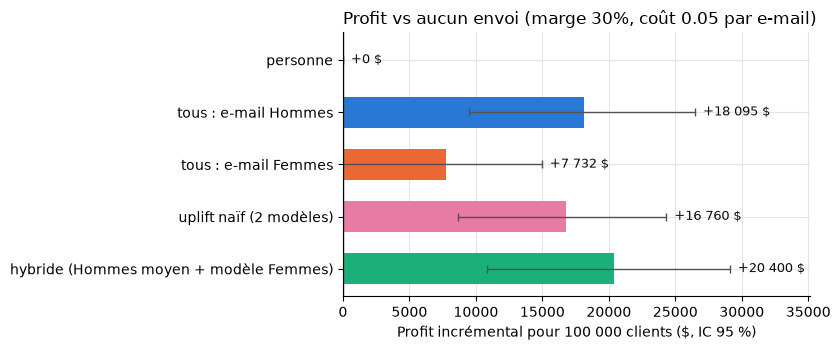

In [6]:
ordre = list(pols.keys())
fig, ax = plt.subplots(figsize=(8.5, 3.6))
y = np.arange(len(ordre))
for i, nom in enumerate(ordre):
    r = resultats.loc[nom]
    ax.barh(i, r["incrémental vs personne"] * 100_000, color=COULEURS[nom], height=0.6)
    ax.errorbar(r["incrémental vs personne"] * 100_000, i,
                xerr=[[(r["incrémental vs personne"] - r["IC95 bas"]) * 100_000], [(r["IC95 haut"] - r["incrémental vs personne"]) * 100_000]],
                fmt="none", ecolor="#52514e", capsize=3, linewidth=1)
    ax.text(max(r["IC95 haut"], 0) * 100_000 + 600, i, f"{r['incrémental vs personne'] * 100_000:+,.0f} $".replace(",", " "),
            va="center", fontsize=9, color="#0b0b0b")
ax.axvline(0, color="#52514e", linewidth=1)
ax.set_yticks(y, ordre)
ax.invert_yaxis()
ax.set_xlabel("Profit incrémental pour 100 000 clients ($, IC 95 %)")
ax.set_title(f"Profit vs aucun envoi (marge {MARGE:.0%}, coût {COUT_EMAIL:.2f} par e-mail)", loc="left")
ax.set_xlim(right=ax.get_xlim()[1] * 1.15)
plt.tight_layout()
plt.savefig("../docs/figures/05_profit_politiques.png", dpi=150)
plt.show()

## 4. Le ciblage selon le coût d'envoi

La décision dépend du coût par e-mail. Quand l'envoi devient cher, il faut cibler, et un **bon** modèle d'uplift devient précieux. On trace le profit incrémental (vs personne) de chaque politique en fonction du coût, à marge fixée à 30 %.

**Seuil de rentabilité théorique de l'e-mail Hommes** : il rapporte $0{,}30 \times 0{,}77 \approx 0{,}23$ $ de marge par client. Au-delà de ce coût, l'envoyer à tous fait perdre de l'argent, et comme son effet est homogène, il n'existe pas de sous-groupe où il rapporterait nettement plus.

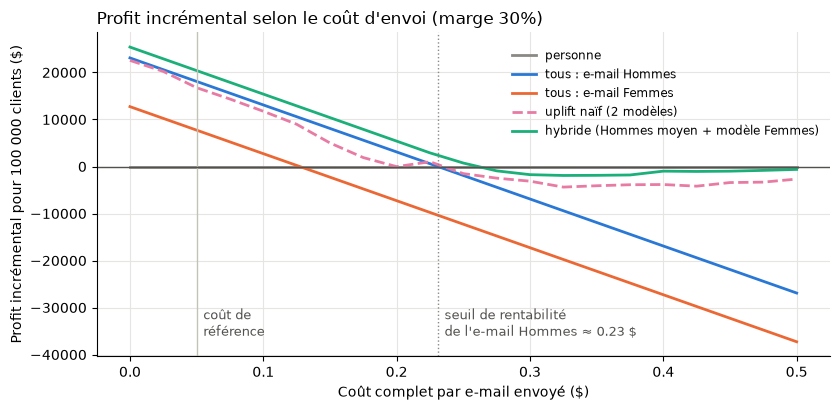

In [7]:
couts = np.round(np.arange(0, 0.51, 0.025), 3)
courbes = {nom: [] for nom in pols}
for c in couts:
    pc = politiques(MARGE, c)
    base = profit(pc["personne"], MARGE, c)
    for nom, pi in pc.items():
        courbes[nom].append((profit(pi, MARGE, c) - base) * 100_000)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for nom, valeurs in courbes.items():
    style = "--" if nom == "uplift naïf (2 modèles)" else "-"
    ax.plot(couts, valeurs, style, color=COULEURS[nom], linewidth=2, label=nom)
ax.axvline(MARGE * ate_hommes, color="#8a8984", linewidth=1, linestyle=":")
ax.text(MARGE * ate_hommes + 0.005, -36000, f"seuil de rentabilité\nde l'e-mail Hommes ≈ {MARGE * ate_hommes:.2f} $", fontsize=9, color="#52514e")
ax.axvline(COUT_EMAIL, color="#c3c2b7", linewidth=1)
ax.text(COUT_EMAIL + 0.005, -36000, "coût de\nréférence", fontsize=9, color="#52514e")
ax.axhline(0, color="#52514e", linewidth=1)
ax.set_xlabel("Coût complet par e-mail envoyé ($)")
ax.set_ylabel("Profit incrémental pour 100 000 clients ($)")
ax.set_title(f"Profit incrémental selon le coût d'envoi (marge {MARGE:.0%})", loc="left")
ax.legend(frameon=False, fontsize=8.5, loc="upper right", bbox_to_anchor=(1.0, 0.98))
plt.tight_layout()
plt.savefig("../docs/figures/05_profit_selon_cout.png", dpi=150)
plt.show()

**Lecture** :
- Sous le seuil (≈ 0,23 $), **« tous e-mail Hommes »** est quasiment optimal. L'hybride le suit de près, un peu au-dessus, mais dans la marge d'erreur.
- Au-delà du seuil, plus aucune politique ne bat clairement « personne ». Les politiques d'uplift limitent la casse en n'envoyant presque plus rien, mais ne trouvent pas de niche rentable.
- L'**uplift naïf** est en dessous de l'hybride sur toute la plage : les mauvaises décisions dues au modèle Hommes coûtent à tous les niveaux de coût.

## 5. Analyse de sensibilité : marge × coût

La recommandation tient-elle si nos hypothèses économiques sont fausses ? On balaie une grille de marges et de coûts, et on regarde **quelle politique uniforme est la meilleure**, et **ce que l'hybride apporte en plus** par rapport à elle.

In [8]:
marges = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60]
couts_grille = [0.0, 0.01, 0.05, 0.10, 0.20, 0.30, 0.50]
meilleure, gain_hybride = pd.DataFrame(index=marges, columns=couts_grille), pd.DataFrame(index=marges, columns=couts_grille, dtype=float)
for m in marges:
    for c in couts_grille:
        pc = politiques(m, c)
        uniformes = {nom: profit(pc[nom], m, c) for nom in ["personne", "tous : e-mail Hommes", "tous : e-mail Femmes"]}
        nom_max = max(uniformes, key=uniformes.get)
        meilleure.loc[m, c] = {"personne": "personne", "tous : e-mail Hommes": "Hommes", "tous : e-mail Femmes": "Femmes"}[nom_max]
        gain_hybride.loc[m, c] = (profit(pc["hybride (Hommes moyen + modèle Femmes)"], m, c) - uniformes[nom_max]) * 100_000
meilleure.index = [f"marge {m:.0%}" for m in marges]
meilleure.columns = [f"coût {c:.2f} $" for c in couts_grille]
print("Meilleure politique uniforme :")
meilleure

Meilleure politique uniforme :


,coût 0.00 $,coût 0.01 $,coût 0.05 $,coût 0.10 $,coût 0.20 $,coût 0.30 $,coût 0.50 $
marge 10%,Hommes,Hommes,Hommes,personne,personne,personne,personne
marge 20%,Hommes,Hommes,Hommes,Hommes,personne,personne,personne
marge 30%,Hommes,Hommes,Hommes,Hommes,Hommes,personne,personne
marge 40%,Hommes,Hommes,Hommes,Hommes,Hommes,Hommes,personne
marge 50%,Hommes,Hommes,Hommes,Hommes,Hommes,Hommes,personne
marge 60%,Hommes,Hommes,Hommes,Hommes,Hommes,Hommes,personne


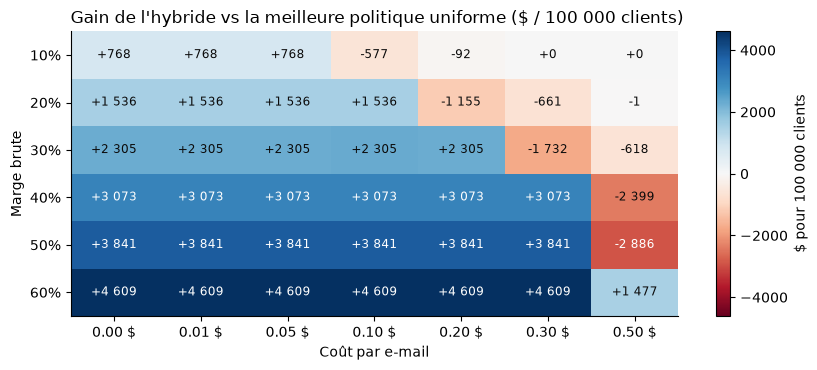

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
valeurs = gain_hybride.to_numpy(dtype=float)
limite = np.abs(valeurs).max()
image = ax.imshow(valeurs, cmap="RdBu", vmin=-limite, vmax=limite, aspect="auto")
for i in range(len(marges)):
    for j in range(len(couts_grille)):
        ax.text(j, i, f"{valeurs[i, j]:+,.0f}".replace(",", " "), ha="center", va="center", fontsize=8.5,
                color="#0b0b0b" if abs(valeurs[i, j]) < limite * 0.6 else "white")
ax.set_xticks(range(len(couts_grille)), [f"{c:.2f} $" for c in couts_grille])
ax.set_yticks(range(len(marges)), [f"{m:.0%}" for m in marges])
ax.set_xlabel("Coût par e-mail")
ax.set_ylabel("Marge brute")
ax.grid(False)
fig.colorbar(image, ax=ax, label="$ pour 100 000 clients")
ax.set_title("Gain de l'hybride vs la meilleure politique uniforme ($ / 100 000 clients)", loc="left")
plt.tight_layout()
plt.savefig("../docs/figures/05_sensibilite.png", dpi=150)
plt.show()

**Lecture** :
- **La meilleure politique uniforme** suit une règle simple. On envoie l'e-mail Hommes à tous tant que $\text{coût} < \text{marge} \times 0{,}77$ $. Sinon, on n'envoie rien. L'e-mail Femmes n'est jamais la meilleure politique uniforme.
- **Le gain de l'hybride** est modeste partout. Il est positif tant que l'e-mail Hommes est rentable : on y remplace l'e-mail Hommes par l'e-mail Femmes là où le modèle le juge meilleur. Il devient légèrement négatif dans la zone où il vaudrait mieux ne rien envoyer : le modèle y trouve des « niches » rentables pour l'e-mail Femmes qui ne se confirment pas. De l'ordre de quelques milliers de $ pour 100 000 clients, ce gain reste du même ordre que l'incertitude de la section 3.

## 6. Faut-il déployer l'hybride ? Ce que coûterait la preuve

L'hybride gagne ≈ +0,02 $ de profit par client, soit ≈ +0,08 $ de chiffre d'affaires à marge 30 %. Peut-on le **prouver** par un nouveau test A/B « hybride vs tous Hommes » ? La formule de la phase 3 (MDE ≈ 2,8 erreurs standard) donne l'ordre de grandeur. Les deux bras ne diffèrent que pour le client sur cinq qui change d'e-mail, mais l'écart-type de la dépense par client (≈ 15-18 $) reste le bruit de fond.

In [10]:
from scipy import stats

gain_ca = resultats.loc["hybride (Hommes moyen + modèle Femmes)", "vs tous Hommes"] / MARGE
sigma = spend[W != 0].std()
n_par_bras = 2 * ((stats.norm.ppf(0.975) + stats.norm.ppf(0.8)) * sigma / gain_ca) ** 2
print(f"Gain de chiffre d'affaires visé : {gain_ca:.3f} $ / client   (écart-type de la dépense ≈ {sigma:.1f} $)")
print(f"Clients nécessaires par bras pour 80 % de puissance : ≈ {n_par_bras:,.0f}".replace(",", " "))

Gain de chiffre d'affaires visé : 0.077 $ / client   (écart-type de la dépense ≈ 16.5 $)
Clients nécessaires par bras pour 80 % de puissance : ≈ 722 920


**Lecture** : il faudrait de l'ordre de **720 000 clients par bras**, soit ≈ 34 fois la taille de chaque groupe de cette expérience, pour démontrer ce gain. C'est une approximation (les deux bras ne diffèrent que pour un client sur cinq, ce qu'un plan d'expérience plus fin pourrait exploiter), mais l'ordre de grandeur est sans appel. Le gain de la personnalisation est **trop petit pour être prouvé**. On le présente donc comme une **option**, à faible risque et à faible enjeu, et non comme la recommandation principale.

## 7. Recommandation

**Pour une base de 100 000 clients, avec une marge de 30 % et un coût complet de 0,05 $ par e-mail :**

1. **Envoyer l'e-mail Hommes à tous les clients.** C'est la décision robuste :
   - chiffre d'affaires incrémental ≈ **+77 000 $** (+0,77 $ par client, IC95 ≈ [0,49 ; 1,05]) ;
   - profit incrémental ≈ **+18 000 $** après 5 000 $ de coûts d'envoi, soit un **ROI ≈ 3,6** (3,6 $ de profit net par dollar dépensé en envoi) ;
   - valable tant que le coût par e-mail reste **sous ≈ 0,23 $** (à marge 30 % ; plus généralement, sous 0,77 $ × marge).
2. **Ne pas cibler l'e-mail Hommes par un modèle d'uplift** : son effet est homogène, et la politique « uplift naïf » ne fait pas mieux, plutôt moins bien, que l'envoi à tous.
3. **Option de personnalisation, gain modeste et non démontré** : envoyer l'e-mail Femmes plutôt que l'e-mail Hommes au client sur cinq que le modèle juge plus réceptif (surtout les gros clients sans historique d'achat hommes). Gain estimé ≈ +0,02 $ par client (+2 000 $ / 100 000 clients), indémontrable par un test de taille raisonnable. À n'adopter que si la création de deux e-mails ne coûte rien de plus.
4. **Si le coût d'envoi dépasse le seuil** (par exemple un courrier papier ou un bon de réduction plutôt qu'un e-mail), ne pas faire de campagne de masse. Aucune niche rentable n'a été trouvée avec ces données.
5. **Pour la prochaine campagne** : garder un **groupe contrôle** sans e-mail (≈ 10 %) pour continuer à mesurer l'effet, et piloter les tests sur la **visite** (phase 3 : 20 à 35 fois moins de clients nécessaires que pour la dépense).

**Limites** : les hypothèses de marge et de coût sont externes au jeu de données (d'où la section 5). L'effet est mesuré sur **deux semaines**, et l'effet à long terme (fidélisation ou fatigue) est inconnu. Les données datent de 2008, et les ordres de grandeur actuels peuvent différer. Enfin, la politique hybride a été conçue après analyse des mêmes données (phase 4), donc son évaluation est légèrement optimiste.

In [11]:
# Chiffres de la recommandation (pour le README et le rapport)
base = 100_000
ref = resultats.loc["tous : e-mail Hommes"]
print(f"CA incrémental tous Hommes       : {ate_hommes * base:,.0f} $".replace(",", " "))
print(f"Coût d'envoi                     : {COUT_EMAIL * base:,.0f} $".replace(",", " "))
print(f"Profit incrémental               : {ref['incrémental vs personne'] * base:,.0f} $ "
      f"(IC95 {ref['IC95 bas'] * base:,.0f} à {ref['IC95 haut'] * base:,.0f})".replace(",", " "))
print(f"ROI (profit net / coût d'envoi)  : {ref['incrémental vs personne'] / COUT_EMAIL:.1f}")
print(f"Seuil de coût (marge {MARGE:.0%})       : {MARGE * ate_hommes:.3f} $")
hyb = resultats.loc["hybride (Hommes moyen + modèle Femmes)"]
print(f"Gain hybride vs tous Hommes      : {hyb['vs tous Hommes'] * base:,.0f} $ "
      f"(IC95 {hyb['IC95 bas '] * base:,.0f} à {hyb['IC95 haut '] * base:,.0f})".replace(",", " "))

CA incrémental tous Hommes       : 76 983 $
Coût d'envoi                     : 5 000 $
Profit incrémental               : 18 095 $ (IC95 9 482 à 26 489)
ROI (profit net / coût d'envoi)  : 3.6
Seuil de coût (marge 30%)       : 0.231 $
Gain hybride vs tous Hommes      : 2 305 $ (IC95 -1 634 à 6 722)
